# In vivo temperature measurements analysis

In [144]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [145]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *
from usnm2p.fileops import *
from usnm2p.utils import get_singleton

### Inputs

In [146]:
dataroot = get_thermal_data_root()
experiments = ['20260910_M01', '20260911_M02']
datadirs = [os.path.join(dataroot, exp) for exp in experiments]

# Root directory for output figures
figsdir = os.path.join(dataroot, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)
logger.info(f'output figures directory: "{figsdir}"')

# Figures dictionary
figs = {}

 2026/09/18 15:37:55: root data directory: "/Users/tlemaire/Documents/data/US_thermal_experiments"
 2026/09/18 15:37:55: output figures directory: "/Users/tlemaire/Documents/data/US_thermal_experiments/figs"


### Load data

In [157]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadirs, plot=True, figdict=figs)

# Rename index dimensions:
# - "condition" -> "location"
data = data.rename_axis(index={Label.CONDITION: Label.LOCATION})
# Strip date from specimen index dimension
data = data.rename(index=lambda x: x.split('_', 1)[1], level=Label.SPECIMEN)

# Compute ISPPA and ISPTA columns
data[Label.ISPPA] = pressure_to_intensity(data[Label.P] / PA_TO_MPA) / M2_TO_CM2  # W/cm2
data[Label.ISPTA] = data[Label.ISPPA] * data[Label.DC] / 1e2
for k in [Label.ISPPA, Label.ISPTA]:
    data[k] = data[k].round(2)

# Extract experimental duty cycle
DC = get_singleton(data, Label.DC)

# Restrict trial data to up to 5s post-stimulation
logger.info('restricting trial data to up to 5s post-stimulation')
data = data[data.index.get_level_values(Label.TIME) < 5.].copy()

logger.info('processed experiment data:')
data

 2026/09/18 15:39:26: -------------------------------loading data for specimen 20260910_M01-------------------------------
 2026/09/18 15:39:26: loading processed data from "thermal_experiment_processed_dataM01_T02_glass1layer_2.095MHz_V1_center_300um.h5"
 2026/09/18 15:39:26: loading processed data from "thermal_experiment_processed_dataM01_T02_glass1layer_2.095MHz_V1_center_1300um.h5"
 2026/09/18 15:39:26: loading processed data from "thermal_experiment_processed_dataM01_T02_glass1layer_2.095MHz_V1_lateral1000um_300um.h5"
 2026/09/18 15:39:27: -------------------------------loading data for specimen 20260911_M02-------------------------------
 2026/09/18 15:39:27: loading processed data from "thermal_experiment_processed_dataM02_T02_glass1layer_2.095MHz_V1_center_300um.h5"
 2026/09/18 15:39:27: loading processed data from "thermal_experiment_processed_dataM02_T02_glass1layer_2.095MHz_V1_center_1300um.h5"
 2026/09/18 15:39:27: loading processed data from "thermal_experiment_processed_

T (°C)  \
specimen location               trial time (s)               
M01      V1_center_1300um       0     -0.641675  30.925308   
                                      -0.633325  30.926714   
                                      -0.624975  30.929782   
                                      -0.616625  30.930223   
                                      -0.608275  30.929645   
...                                                    ...   
M02      V1_lateral1000um_300um 44     4.961175  25.045525   
                                       4.969525  25.045117   
                                       4.977875  25.046914   
                                       4.986225  25.047669   
                                       4.994575  25.046789   

                                                                 timestamp  \
specimen location               trial time (s)                               
M01      V1_center_1300um       0     -0.641675 2026-09-10 15:42:13.789000   
                                      -0.633325 2026-09-10 15:42:13.789000   
                                      -0.624975 2026-09-10 15:42:13.789000   
                                      -0.616625 2026-09-10 15:42:13.789000   
                                      -0.608275 2026-09-10 15:42:13.789000   
...                                                                    ...   
M02      V1_lateral1000um_300um 44     4.961175 2026-09-11 12:32:14.180217   
                                       4.969525 2026-09-11 12:32:14.180217   
                                       4.977875 2026-09-11 12:32:14.180217   
                                       4.986225 2026-09-11 12:32:14.180217   
                                       4.994575 2026-09-11 12:32:14.180217   

                                                 Fdrive (MHz)  P (MPa)  \
specimen location               trial time (s)                           
M01      V1_center_1300um       0     -0.641675         2.095     2.29   
                                      -0.633325         2.095     2.29   
                                      -0.624975         2.095     2.29   
                                      -0.616625         2.095     2.29   
                                      -0.608275         2.095     2.29   
...                                                       ...      ...   
M02      V1_lateral1000um_300um 44     4.961175         2.095     0.00   
                                       4.969525         2.095     0.00   
                                       4.977875         2.095     0.00   
                                       4.986225         2.095     0.00   
                                       4.994575         2.095     0.00   

                                                  Vpp (V)  duration (s)  \
specimen location               trial time (s)                            
M01      V1_center_1300um       0     -0.641675  0.612646           0.2   
                                      -0.633325  0.612646           0.2   
                                      -0.624975  0.612646           0.2   
                                      -0.616625  0.612646           0.2   
                                      -0.608275  0.612646           0.2   
...                                                   ...           ...   
M02      V1_lateral1000um_300um 44     4.961175  0.000000           0.2   
                                       4.969525  0.000000           0.2   
                                       4.977875  0.000000           0.2   
                                       4.986225  0.000000           0.2   
                                       4.994575  0.000000           0.2   

                                                 PRF (Hz)  DC (%)  \
specimen location               trial time (s)                      
M01      V1_center_1300um       0     -0.641675     100.0    80.0   
                                      -0.633325     100.0    80.0   
               

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [158]:
# Apply trial-by-trial linear detrending to the temperature data
gby = excluded(data.index, Label.TIME)
logger.info(f'detrending temperature traces for each {gby} combination')
data[f'detrended {Label.TEMP}'] = (
    data
    .groupby(gby)
    [Label.TEMP]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[Label.REL_TEMP] = (
    data
    .groupby(gby)
    [f'detrended {Label.TEMP}']
    .transform(compute_deltaT)
)

data

 2026/09/18 15:39:32: detrending temperature traces for each ['specimen', 'location', 'trial'] combination
 2026/09/18 15:39:33: computing trial-by-trial relative temperature change


T (°C)  \
specimen location               trial time (s)               
M01      V1_center_1300um       0     -0.641675  30.925308   
                                      -0.633325  30.926714   
                                      -0.624975  30.929782   
                                      -0.616625  30.930223   
                                      -0.608275  30.929645   
...                                                    ...   
M02      V1_lateral1000um_300um 44     4.961175  25.045525   
                                       4.969525  25.045117   
                                       4.977875  25.046914   
                                       4.986225  25.047669   
                                       4.994575  25.046789   

                                                                 timestamp  \
specimen location               trial time (s)                               
M01      V1_center_1300um       0     -0.641675 2026-09-10 15:42:13.789000   
                                      -0.633325 2026-09-10 15:42:13.789000   
                                      -0.624975 2026-09-10 15:42:13.789000   
                                      -0.616625 2026-09-10 15:42:13.789000   
                                      -0.608275 2026-09-10 15:42:13.789000   
...                                                                    ...   
M02      V1_lateral1000um_300um 44     4.961175 2026-09-11 12:32:14.180217   
                                       4.969525 2026-09-11 12:32:14.180217   
                                       4.977875 2026-09-11 12:32:14.180217   
                                       4.986225 2026-09-11 12:32:14.180217   
                                       4.994575 2026-09-11 12:32:14.180217   

                                                 Fdrive (MHz)  P (MPa)  \
specimen location               trial time (s)                           
M01      V1_center_1300um       0     -0.641675         2.095     2.29   
                                      -0.633325         2.095     2.29   
                                      -0.624975         2.095     2.29   
                                      -0.616625         2.095     2.29   
                                      -0.608275         2.095     2.29   
...                                                       ...      ...   
M02      V1_lateral1000um_300um 44     4.961175         2.095     0.00   
                                       4.969525         2.095     0.00   
                                       4.977875         2.095     0.00   
                                       4.986225         2.095     0.00   
                                       4.994575         2.095     0.00   

                                                  Vpp (V)  duration (s)  \
specimen location               trial time (s)                            
M01      V1_center_1300um       0     -0.641675  0.612646           0.2   
                                      -0.633325  0.612646           0.2   
                                      -0.624975  0.612646           0.2   
                                      -0.616625  0.612646           0.2   
                                      -0.608275  0.612646           0.2   
...                                                   ...           ...   
M02      V1_lateral1000um_300um 44     4.961175  0.000000           0.2   
                                       4.969525  0.000000           0.2   
                                       4.977875  0.000000           0.2   
                                       4.986225  0.000000           0.2   
                                       4.994575  0.000000           0.2   

                                                 PRF (Hz)  DC (%)  \
specimen location               trial time (s)                      
M01      V1_center_1300um       0     -0.641675     100.0    80.0   
                                      -0.633325     100.0    80.0   
               

### Plot stim-evoked temperature traces across locations

 2026/09/18 15:38:10: plotting stimulus-evoked temperature traces across mice and locations
 2026/09/18 15:38:22: plotting across-mice average stimulus-evoked temperature traces across locations


Text(0.5, 1.05, 'cross-mice average of thermal response traces across locations')

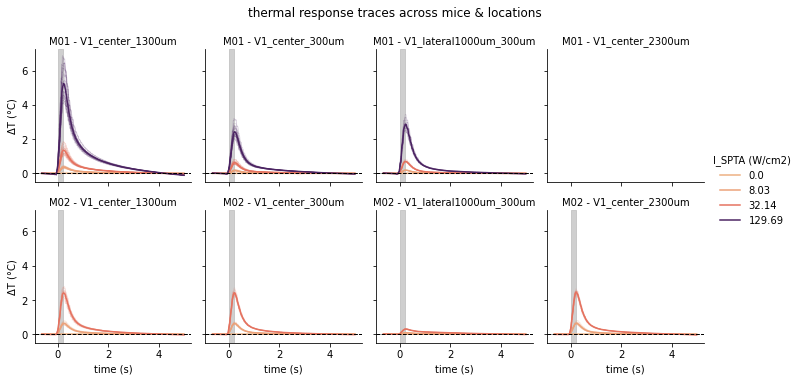

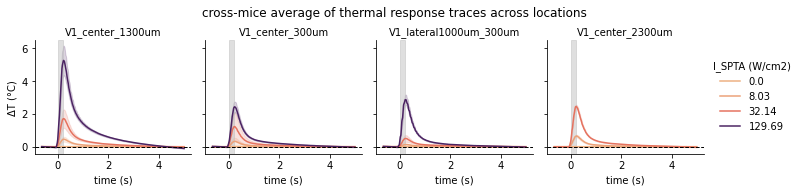

In [149]:
# Plot stim-evoked temperature traces for each mouse - location combination
logger.info('plotting stimulus-evoked temperature traces across mice and locations')
figkey = 'thermal response traces across mice & locations'
g = sns.FacetGrid(
    data=data.reset_index(),
    col=Label.LOCATION,
    row=Label.SPECIMEN,
    height=2.5,
)
g.set_titles(template='{row_name} - {col_name}')
for units in [Label.TRIAL, None]:
    g.map_dataframe(
        plot_evoked_thermal_response,
        y=Label.REL_TEMP, 
        units=units,
        estimator=None if units is not None else np.mean,
        errorbar=None,
        alpha=0.2 if units is not None else 1.0,
        lw=0.5 if units is not None else 1.5,
        legend='full' if units is None else False,
        **TRACE_HUE_KWARGS
    )
g.add_legend(title=TRACE_HUE_KWARGS['hue'])
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

# Plot stim-evoked temperature traces for each location
logger.info('plotting across-mice average stimulus-evoked temperature traces across locations')
figkey = 'cross-mice average of thermal response traces across locations'
g = sns.FacetGrid(
    data=data.reset_index(),
    col=Label.LOCATION,
    height=2.5,
)
g.set_titles(template='{col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=Label.REL_TEMP, 
    errorbar='sd',
    **TRACE_HUE_KWARGS
)
g.add_legend(title=TRACE_HUE_KWARGS['hue'])
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Aggregate traces across trials for each condition 

In [150]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/18 15:38:40: computing trial-average data by ['specimen', 'location', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)']


T (°C)  \
specimen location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)               
M01      V1_center_1300um       0.00    0.00           0.00           -0.641675  31.193681   
                                                                      -0.633325  31.193336   
                                                                      -0.624975  31.193235   
                                                                      -0.616625  31.193838   
                                                                      -0.608275  31.194601   
...                                                                                    ...   
M02      V1_lateral1000um_300um 1.14    40.17          32.14           4.961175  27.118022   
                                                                       4.969525  27.116740   
                                                                       4.977875  27.117198   
                                                                       4.986225  27.118362   
                                                                       4.994575  27.118353   

                                                                                 Fdrive (MHz)  \
specimen location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)                  
M01      V1_center_1300um       0.00    0.00           0.00           -0.641675         2.095   
                                                                      -0.633325         2.095   
                                                                      -0.624975         2.095   
                                                                      -0.616625         2.095   
                                                                      -0.608275         2.095   
...                                                                                       ...   
M02      V1_lateral1000um_300um 1.14    40.17          32.14           4.961175         2.095   
                                                                       4.969525         2.095   
                                                                       4.977875         2.095   
                                                                       4.986225         2.095   
                                                                       4.994575         2.095   

                                                                                  Vpp (V)  \
specimen location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
M01      V1_center_1300um       0.00    0.00           0.00           -0.641675  0.000000   
                                                                      -0.633325  0.000000   
                                                                      -0.624975  0.000000   
                                                                      -0.616625  0.000000   
                                                                      -0.608275  0.000000   
...                                                                                   ...   
M02      V1_lateral1000um_300um 1.14    40.17          32.14           4.961175  0.257133   
                                                                       4.969525  0.257133   
                                                                       4.977875  0.257133   
                                                                       4.986225  0.257133   
                                                                       4.994575  0.257133   

                                                                                  ΔT (°C)  \
specimen location               P (MPa) I_SPPA (W/cm2) I_SPTA (W/cm2) time (s)              
M01      V1_center_1300um       0.00    0.00           0.00           -0.641675  0.001548   
                                                                      -0.633325  0.001235   
                 

### Fit double exponential to temperature data

 2026/09/18 15:38:40: fitting double exponential to trial-averaged temperature traces


 2026/09/18 15:38:42: constructing fitted double exponential traces
 2026/09/18 15:38:42: plotting t_0 (s) distribution
 2026/09/18 15:38:42: plotting peak (°C) distribution
 2026/09/18 15:38:42: plotting τ_rise (s) distribution
 2026/09/18 15:38:42: plotting τ_decay (s) distribution
 2026/09/18 15:38:42: plotting offset (°C) distribution


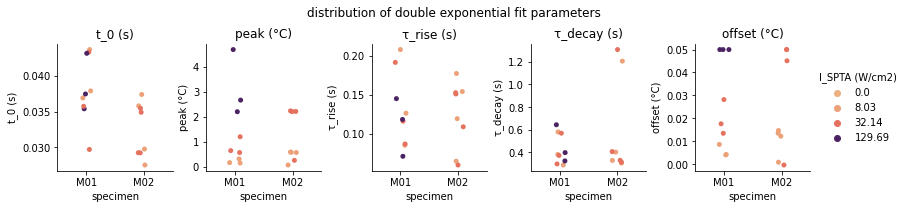

In [151]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = excluded(aggdata.index, Label.TIME)
groups = aggdata.groupby(gby)[Label.REL_TEMP]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {Label.REL_TEMP}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(Label.TIME).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(Label.TIME))
)

naxes = len(fits.columns)
figkey = 'distribution of double exponential fit parameters'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(2.5 * naxes, 2.5), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.stripplot(
        ax=ax,
        data=fits.reset_index(),
        x=Label.SPECIMEN,
        y=k,
        **TRACE_HUE_KWARGS,
        legend=ax is axes[-1],
    )
    ax.set_title(k)
    sns.despine(ax=ax)
sns.move_legend(axes[-1], 'center left', bbox_to_anchor=(1, 0.5), frameon=False)
figs[figkey].suptitle(figkey, y=1.1);

### Plot trial-averaged stim-evoked temperature traces and fitted double exponential traces

 2026/09/18 15:38:43: plotting stimulus-evoked temperature traces per mouse & location


Text(0.5, 1.05, 'trial-average response traces (with double-exponential fits) across mice & locations')

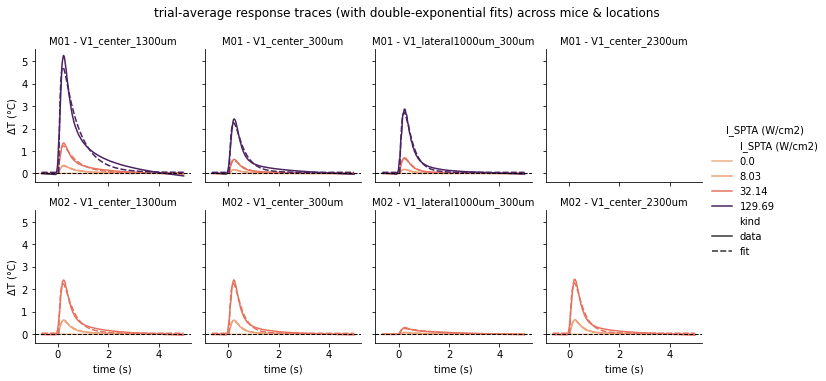

In [152]:
# Melt data by data/fit kind for plotting
ymap = {
    Label.REL_TEMP: 'data',
    f'fitted {Label.REL_TEMP}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
logger.info(f'plotting stimulus-evoked temperature traces per mouse & location')
figkey = 'trial-average response traces (with double-exponential fits) across mice & locations'
g = sns.FacetGrid(
    data=melted_data.reset_index(),
    col=Label.LOCATION,
    row=Label.SPECIMEN,
    height=2.5,
)
g.set_titles(template='{row_name} - {col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=Label.REL_TEMP,
    style='kind',
    **TRACE_HUE_KWARGS
)
g.add_legend(title=TRACE_HUE_KWARGS['hue'])
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Compute max-evoked temperature change for each condition

In [153]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data)
logger.info(f'computing max-evoked temperature change for each {cond_keys} combination')
max_evoked_change = (
    data
    .groupby([*cond_keys, Label.TRIAL])
    [Label.REL_TEMP]
    .max()
    .rename(Label.MAX_REL_TEMP)
)
max_evoked_change

logger.info(f'computing average max-evoked temperature change for each {cond_keys} combination')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

agg_max_evoked_change

 2026/09/18 15:38:47: computing max-evoked temperature change for each ['specimen', 'location', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)'] combination
 2026/09/18 15:38:47: computing average max-evoked temperature change for each ['specimen', 'location', 'P (MPa)', 'I_SPPA (W/cm2)', 'I_SPTA (W/cm2)'] combination


specimen  location                P (MPa)  I_SPPA (W/cm2)  I_SPTA (W/cm2)
M01       V1_center_1300um        0.00     0.00            0.00              0.033387
                                  0.57     10.04           8.03              0.367162
                                  1.14     40.17           32.14             1.363163
                                  2.29     162.11          129.69            5.283803
          V1_center_300um         0.00     0.00            0.00              0.025319
                                  0.57     10.04           8.03              0.172420
                                  1.14     40.17           32.14             0.634189
                                  2.29     162.11          129.69            2.445104
          V1_lateral1000um_300um  0.00     0.00            0.00              0.026634
                                  0.57     10.04           8.03              0.189933
                                  1.14     40.17           32.14  

### Plot dose-dependence of evoked temperature change at each location

 2026/09/18 15:38:48: plotting pressure dependence of temperature change of M01 at V1_center_1300um
 2026/09/18 15:38:48: plotting ISPTA-dependent evoked temperature change traces
 2026/09/18 15:38:50: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/18 15:38:50: least-square linear fit: slope = 0.041 °C/(W/cm²), R² = 0.95
 2026/09/18 15:38:50: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/18 15:38:50: predicted max-evoked temperature change at 15.83 W/cm²: 0.647 °C
 2026/09/18 15:38:50: plotting pressure dependence of temperature change of M01 at V1_center_300um
 2026/09/18 15:38:51: plotting ISPTA-dependent evoked temperature change traces
 2026/09/18 15:38:52: performing least-square linear fit on max_ΔT vs ISPTA
 2026/09/18 15:38:52: least-square linear fit: slope = 0.019 °C/(W/cm²), R² = 0.97
 2026/09/18 15:38:52: plotting ISPTA-dependence of max-evoked temperature change at focus
 2026/09/18 15:38:52: predicted max-evoked temperature c

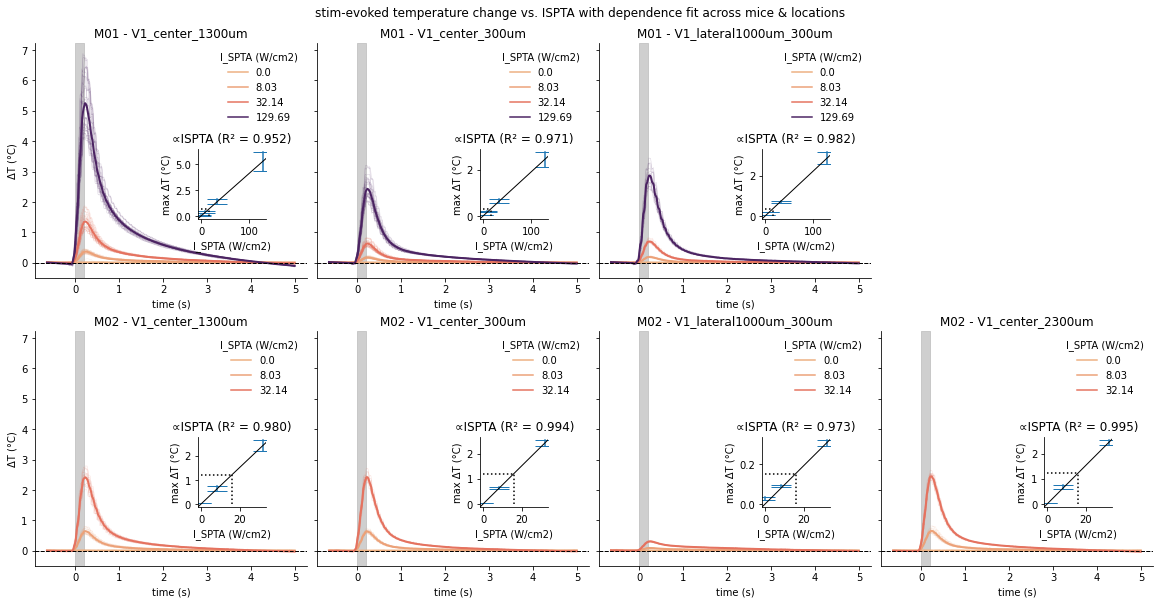

In [154]:
# Compute target ISPTA value corresponding to the reference pressure P_REF and experimental duty cycle DC
target_ISPPA = pressure_to_intensity(P_REF / PA_TO_MPA) / M2_TO_CM2  # W/cm2
target_ISPTA = np.round(target_ISPPA * DC / 1e2, 2)  # W/cm2

# Plot pressure dependence of temperature change at each mouse & location, with linear fit and R² value
specimen = data.index.unique(Label.SPECIMEN)
locs = data.index.unique(Label.LOCATION)
nrows, ncols = len(specimen), len(locs)
figkey = 'stim-evoked temperature change vs. ISPTA with dependence fit across mice & locations'
figs[figkey], axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True, constrained_layout=True)
figs[figkey].suptitle(figkey, y=1.03)
max_ΔT_pred_at_target_ISPTA = pd.DataFrame(index=locs, columns=specimen, dtype=float)
for (spec, gdata), axrow in zip(data.groupby(Label.SPECIMEN), axes):
    for loc, ax in zip(locs, axrow):
        logger.info(f'plotting pressure dependence of temperature change of {spec} at {loc}')
        mux_slice = pd.IndexSlice[spec, loc, :]
        try:
            loc_data = gdata.loc[mux_slice]
            loc_max_evoked_change = max_evoked_change.loc[mux_slice]
        except KeyError:
            logger.warning(f'no data for {spec} at {loc}')
            ax.axis('off')
            continue
        _, max_ΔT_pred_at_target_ISPTA.loc[loc, spec] = plot_ispta_dependence(
            loc_data, loc_max_evoked_change, title=f'{spec} - {loc}', ax=ax, Itarget=target_ISPTA)

### Plot estimated max-evoked temperature change at target exposure level for each location

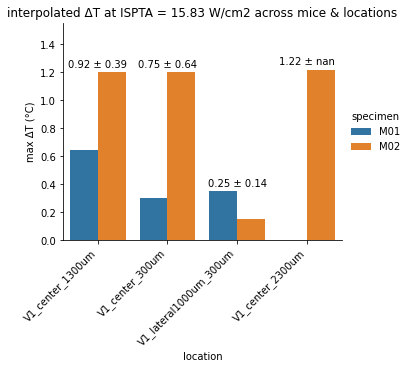

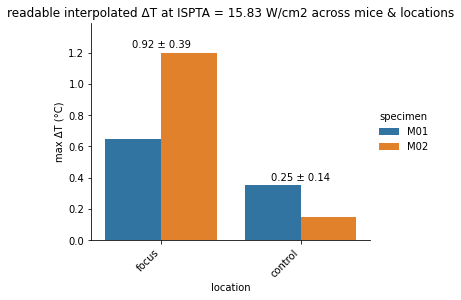

In [155]:
# Plot bar graph of max ΔT predicted at target ISPTA across mice & locations
figkey = f'interpolated ΔT at ISPTA = {target_ISPTA} W/cm2 across mice & locations'
figs[figkey] = plot_max_deltaT_per_location(
    max_ΔT_pred_at_target_ISPTA, figkey)

# Plot the same thing with human readable focus and lateral control locations
locmap = {
    'V1_center_1300um': 'focus',
    'V1_lateral1000um_300um': 'control'
}
readable_max_ΔT_pred_at_target_ISPTA = (
    max_ΔT_pred_at_target_ISPTA
    .loc[locmap.keys()]
    .rename(index=locmap)
)
figkey = f'readable {figkey}'
figs[figkey] = plot_max_deltaT_per_location(
    readable_max_ΔT_pred_at_target_ISPTA, figkey)

### Save figures

In [156]:
save_figs_book(figsdir, figs, suffix='invivo')

 2026/09/18 15:39:09: saving figures in /Users/tlemaire/Documents/data/US_thermal_experiments/figs/2026.09.18/figs_invivo.pdf:


100%|██████████| 7/7 [00:04<00:00,  1.53it/s]
